<a href="https://colab.research.google.com/github/HoniTahina/-arene-des-algos-Tahina-HONI-RIKA/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 0: Récupérer la donnée et l'ouvrir

In [67]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Phase 1: L'audit qualité

In [68]:
def audit_qualite(df):
    # 1. Dimensions
    print(f"Lignes, Colonnes: ({df.shape[0]}, {df.shape[1]})" )
    print("--------------------------")
    # 2. Types des colonnes
    print(df.dtypes)
    print("--------------------------")
    # 3. Valeurs manquantes
    manquants = df.isnull().sum()
    manquant_pct = (manquants / len(df) * 100).round(2)

    rapport_missing = pd.DataFrame({
        "Nombre": manquants,
        "Pourcentage (%)": manquant_pct
    }).sort_values(by="Nombre", ascending=False)
    manquants = manquants[manquants > 0]

    if len(manquants) == 0:
        print("Aucune valeur manquante")
    else:
      print(rapport_missing)
    print("--------------------------")

    # 4. Répartition de la cible
    effectifs = df["Churn"].value_counts()
    pourcentages = df["Churn"].value_counts(normalize=True) * 100
    ratio = effectifs / len(df)
    repartition = pd.DataFrame({
        "Nombre": effectifs,
        "Pourcentage (%)": pourcentages.round(2)
    })
    if ratio.max() > 0.7:
      print("Classe déséquilibrée")
    else:
      print("Classe équilibrée")
    print(repartition)

In [69]:
audit_qualite(df)

Lignes, Colonnes: (7043, 21)
--------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
--------------------------
Aucune valeur manquante
--------------------------
Classe déséquilibrée
       Nombre  Pourcentage (%)
Churn                         
No       5174            73.46
Yes      1869            26.54


In [64]:
# CAS LIMITE : une seule classe
df_single_class = df[df["Churn"] == "No"]

audit_qualite(df_single_class)

Lignes, Colonnes: (5174, 21)
--------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
--------------------------
Aucune valeur manquante
--------------------------
Classe déséquilibrée
       Nombre  Pourcentage (%)
Churn                         
No       5174            100.0


Résultat :

le code ne plante pas
Mais on obtiens :
No: 100%
Yes: n’existe pas
>perte d’information critique : absence totale d’une classe

Phase 2: La colonne piégée (types incohérents et trous cachés)

In [70]:
import numpy as np

def reparer_total_charges(df):
    df = df.copy()

    col = "TotalCharges"

    # 1. détecter valeurs problématiques AVANT conversion
    raw = df[col].astype(str)

    espaces = (raw.str.strip() == "").sum()

    # détection virgule (cas adversarial)
    virgules = raw.str.contains(",", na=False).sum()

    print(f"Valeurs vides cachées (' ') : {espaces}")
    print(f"Valeurs avec virgule suspecte : {virgules}")

    # 2. conversion safe
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # 3. NaN révélés
    nan_count = df[col].isna().sum()
    print(f"Total NaN après conversion : {nan_count}")

    # 4. traitement (choix justifié)
    mediane = df[col].median()

    df[col] = df[col].fillna(mediane)

    print(f"NaN restants après imputation : {df[col].isna().sum()}")

    return df

In [71]:
df = reparer_total_charges(df)
audit_qualite(df)

Valeurs vides cachées (' ') : 11
Valeurs avec virgule suspecte : 0
Total NaN après conversion : 11
NaN restants après imputation : 0
Lignes, Colonnes: (7043, 21)
--------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
--------------------------
Aucune valeur manquante
--------------------------
Classe déséquilibrée
       Nombre  Pourcentage (%)
Churn                         
No       5174            73.46
Yes      1869    

Phase 3:Encoderles catégorielles

In [72]:
def encoder_features(df):
    df = df.copy()

    # 1. Identifier les colonnes catégorielles
    cat_cols = df.select_dtypes(include=["object"]).columns

    print(f"Colonnes catégorielles détectées : {list(cat_cols)}")

    # 2. Supprimer l'identifiant
    if "customerID" in df.columns:
        df = df.drop(columns=["customerID"])
        print("customerID supprimé (identifiant non informatif)")

    # 3. Encodage Yes/No → 0/1
    binary_map = {"Yes": 1, "No": 0}

    for col in df.columns:
        if df[col].dtype == "object":

            # cas binaire Yes/No
            unique_vals = df[col].dropna().unique()

            if set(unique_vals).issubset({"Yes", "No"}):
                df[col] = df[col].map(binary_map)

    # 4. One-Hot Encoding pour les autres catégorielles
    cat_cols = df.select_dtypes(include=["object"]).columns

    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    print(f"Shape après encodage : {df.shape}")

    # vérification
    print("\nTypes après encodage :")
    print(df.dtypes.value_counts())

    return df

In [73]:
df = encoder_features(df)

Colonnes catégorielles détectées : ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
customerID supprimé (identifiant non informatif)
Shape après encodage : (7043, 42)

Types après encodage :
bool       33
int64       7
float64     2
Name: count, dtype: int64


Phase 4: Traiter les valeurs aberrantes

In [74]:
def detecter_outliers_iqr(df, colonne):
    serie = df[colonne].dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)

    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    outliers = serie[(serie < borne_basse) | (serie > borne_haute)]

    print(f"\nColonne : {colonne}")
    print(f"Borne basse : {borne_basse:.2f}")
    print(f"Borne haute : {borne_haute:.2f}")
    print(f"Nombre d'outliers : {len(outliers)}")

    return borne_basse, borne_haute, outliers

In [75]:
import matplotlib.pyplot as plt

def boxplot_col(df, colonne):
    plt.figure()
    df.boxplot(column=colonne)
    plt.title(f"Boxplot - {colonne}")
    plt.show()


Colonne : tenure
Borne basse : -60.00
Borne haute : 124.00
Nombre d'outliers : 0


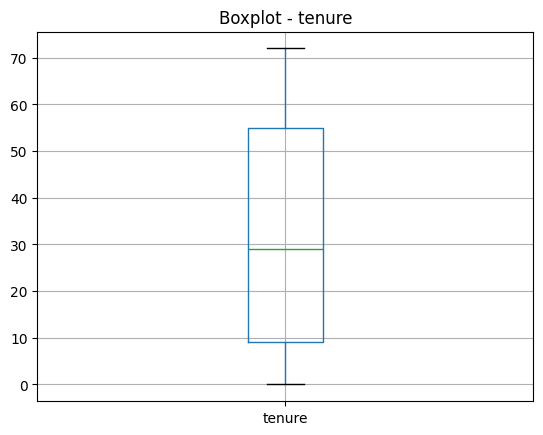


Colonne : MonthlyCharges
Borne basse : -46.02
Borne haute : 171.38
Nombre d'outliers : 0


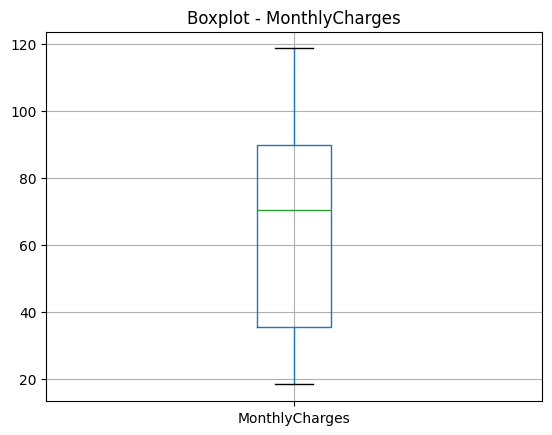


Colonne : TotalCharges
Borne basse : -4674.34
Borne haute : 8863.16
Nombre d'outliers : 0


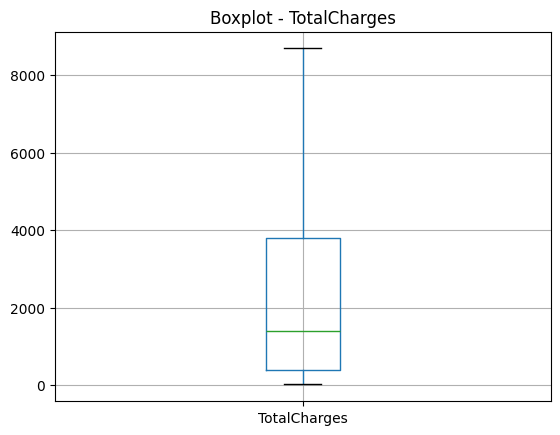

In [76]:
colonnes = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in colonnes:
    detecter_outliers_iqr(df, col)
    boxplot_col(df, col)

Phase 5:  Corrélations et chasse à la multicolinéarité

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


def rapport_multicolinearite(df, colonnes_num):

    # 1. Sous-dataset numérique
    data = df[colonnes_num].dropna().copy()

    # ----------------------------
    # 2. HEATMAP DES CORRÉLATIONS
    # ----------------------------
    corr = data.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Heatmap des corrélations")
    plt.show()

    # ----------------------------
    # 3. CALCUL DU VIF
    # ----------------------------
    vif_data = pd.DataFrame()
    vif_data["variable"] = data.columns
    vif_data["VIF"] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]

    vif_data = vif_data.sort_values(by="VIF", ascending=False)

    print("\nTABLEAU DES VIF :")
    print(vif_data)

    # ----------------------------
    # 4. ALERTES MULTICOLINÉARITÉ
    # ----------------------------
    print("\nVARIABLES AVEC VIF > 5 :")

    high_vif = vif_data[vif_data["VIF"] > 5]

    if high_vif.empty:
        print("Aucune multicolinéarité problématique détectée.")
    else:
        print(high_vif)

    return vif_data

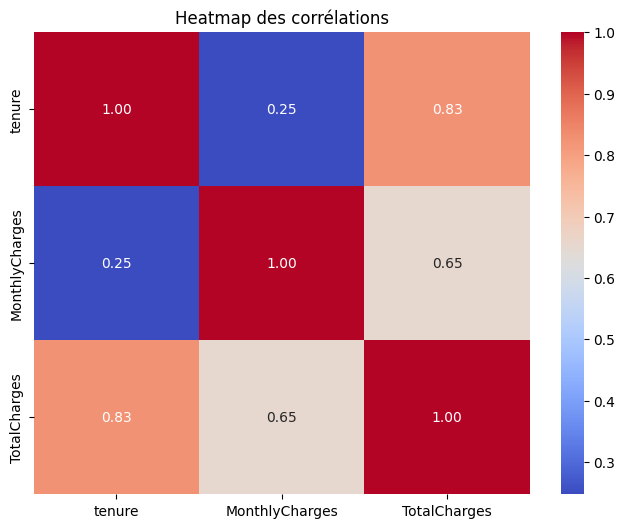


TABLEAU DES VIF :
         variable       VIF
2    TotalCharges  8.073814
0          tenure  6.321802
1  MonthlyCharges  3.360371

VARIABLES AVEC VIF > 5 :
       variable       VIF
2  TotalCharges  8.073814
0        tenure  6.321802


In [78]:
colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges"]

vif = rapport_multicolinearite(df, colonnes_num)

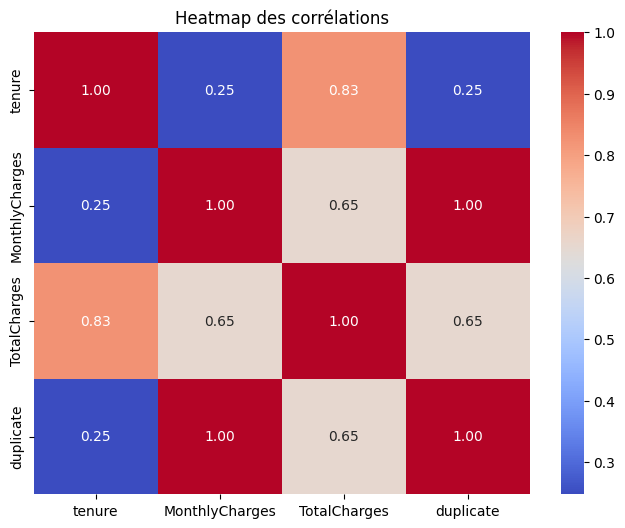


TABLEAU DES VIF :
         variable       VIF
1  MonthlyCharges       inf
3       duplicate       inf
2    TotalCharges  8.073814
0          tenure  6.321802

VARIABLES AVEC VIF > 5 :
         variable       VIF
1  MonthlyCharges       inf
3       duplicate       inf
2    TotalCharges  8.073814
0          tenure  6.321802


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF
1,MonthlyCharges,inf
3,duplicate,inf
2,TotalCharges,8.073814
0,tenure,6.321802


In [79]:
#cas edge
df_test = df.copy()
df_test["duplicate"] = df_test["MonthlyCharges"]

rapport_multicolinearite(df_test, ["tenure", "MonthlyCharges", "TotalCharges", "duplicate"])

AVANT suppression


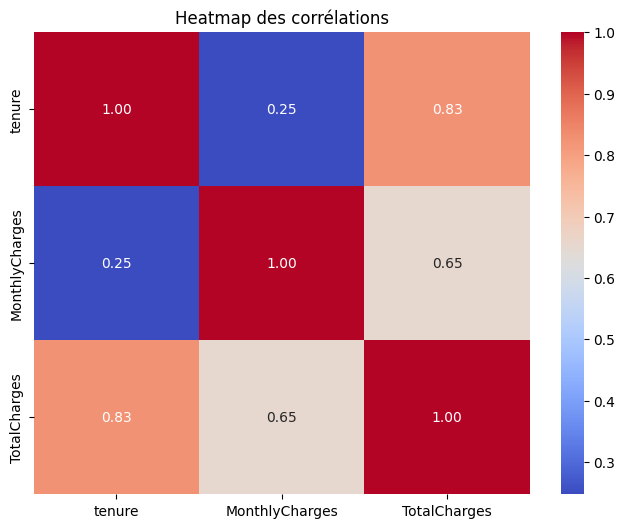


TABLEAU DES VIF :
         variable       VIF
2    TotalCharges  8.073814
0          tenure  6.321802
1  MonthlyCharges  3.360371

VARIABLES AVEC VIF > 5 :
       variable       VIF
2  TotalCharges  8.073814
0        tenure  6.321802
APRÈS suppression


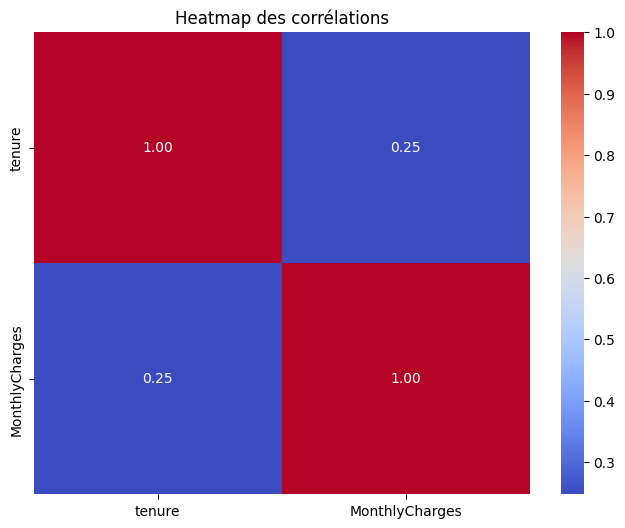


TABLEAU DES VIF :
         variable       VIF
1  MonthlyCharges  2.612607
0          tenure  2.612607

VARIABLES AVEC VIF > 5 :
Aucune multicolinéarité problématique détectée.


,variable,VIF
1,MonthlyCharges,2.612607
0,tenure,2.612607


In [80]:
df2 = df.drop(columns=["TotalCharges"])
print("AVANT suppression")
rapport_multicolinearite(df, ["tenure", "MonthlyCharges", "TotalCharges"])
print("APRÈS suppression")
rapport_multicolinearite(df2, ["tenure", "MonthlyCharges"])

Phase 6:Les variables qui prédisent vraiment le churn

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif


def features_discriminantes(df, cible="Churn"):
    df = df.copy()

    # ----------------------------
    # 1. Encodage cible
    # ----------------------------
    le = LabelEncoder()
    y = le.fit_transform(df[cible])  # Yes/No → 1/0

    X = df.drop(columns=[cible])

    # ----------------------------
    # 2. Encodage des features catégorielles
    # ----------------------------
    X = pd.get_dummies(X, drop_first=False)

    # ----------------------------
    # 3. Méthode 1 : Mutual Information
    # (plus robuste que corrélation brute)
    # ----------------------------
    mi = mutual_info_classif(X, y, random_state=42)

    mi_scores = pd.DataFrame({
        "feature": X.columns,
        "MI_score": mi
    }).sort_values(by="MI_score", ascending=False)

    # ----------------------------
    # 4. Méthode 2 : Random Forest
    # ----------------------------
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rf.fit(X, y)

    rf_scores = pd.DataFrame({
        "feature": X.columns,
        "RF_importance": rf.feature_importances_
    }).sort_values(by="RF_importance", ascending=False)

    # ----------------------------
    # 5. Fusion des classements
    # ----------------------------
    comparaison = pd.merge(
        mi_scores,
        rf_scores,
        on="feature"
    )

    # ----------------------------
    # 6. Affichage top 10
    # ----------------------------
    print("\nTOP 10 FEATURES (Mutual Information)")
    print(mi_scores.head(10))

    print("\nTOP 10 FEATURES (Random Forest)")
    print(rf_scores.head(10))

    print("\nCOMPARAISON TOP 10")
    print(comparaison.head(10))

    return comparaison

In [84]:
# Happy path : dataset normal

classement = features_discriminantes(df, cible="Churn")

print("\nTOP 10 FEATURES :")
print(classement.head(10))

# Vérification simple (Contract doit apparaître haut)
print("\nRecherche de Contract dans le top :")
print(classement[classement["feature"].str.contains("Contract")].head())


TOP 10 FEATURES (Mutual Information)
                           feature  MI_score
34         Contract_Month-to-month  0.090257
3                           tenure  0.076364
36               Contract_Two year  0.063694
25                  TechSupport_No  0.056333
16               OnlineSecurity_No  0.054534
6                   MonthlyCharges  0.048323
14     InternetService_Fiber optic  0.046983
19                 OnlineBackup_No  0.045992
7                     TotalCharges  0.043794
39  PaymentMethod_Electronic check  0.042924

TOP 10 FEATURES (Random Forest)
                           feature  RF_importance
7                     TotalCharges       0.170505
3                           tenure       0.148100
6                   MonthlyCharges       0.146729
34         Contract_Month-to-month       0.055708
16               OnlineSecurity_No       0.031822
25                  TechSupport_No       0.030025
39  PaymentMethod_Electronic check       0.028969
5                 PaperlessBilling

In [85]:
df_test = df.copy()

# colonne constante
df_test["constant_col"] = 1

# faux identifiant (si mal géré)
df_test["fake_id"] = range(len(df_test))

classement_edge = features_discriminantes(df_test, cible="Churn")

print("\nTOP 10 EDGE CASE :")
print(classement_edge.head(10))

# vérifier que constant et ID sont en bas
print("\nFeatures suspectes :")
print(classement_edge[
    classement_edge["feature"].isin(["constant_col", "fake_id"])
])


TOP 10 FEATURES (Mutual Information)
                           feature  MI_score
34         Contract_Month-to-month  0.089639
3                           tenure  0.076222
16               OnlineSecurity_No  0.060538
36               Contract_Two year  0.058138
25                  TechSupport_No  0.057508
14     InternetService_Fiber optic  0.055027
6                   MonthlyCharges  0.045548
7                     TotalCharges  0.043687
15              InternetService_No  0.041897
39  PaymentMethod_Electronic check  0.041109

TOP 10 FEATURES (Random Forest)
                           feature  RF_importance
7                     TotalCharges       0.139043
3                           tenure       0.133589
6                   MonthlyCharges       0.119302
42                         fake_id       0.114423
34         Contract_Month-to-month       0.051394
16               OnlineSecurity_No       0.032739
25                  TechSupport_No       0.026115
14     InternetService_Fiber optic

In [86]:
df_adv = df.copy()

# création d'une feature non linéaire liée au churn
df_adv["non_linear_feature"] = df_adv["tenure"] ** 2

classement_adv = features_discriminantes(df_adv, cible="Churn")

print("\nTOP 10 ADVERSARIAL :")
print(classement_adv.head(10))

# comparaison MI vs RF pour la feature créée
print("\nAnalyse feature non linéaire :")
print(classement_adv[
    classement_adv["feature"].str.contains("non_linear_feature")
])


TOP 10 FEATURES (Mutual Information)
                           feature  MI_score
34         Contract_Month-to-month  0.097648
3                           tenure  0.080060
41              non_linear_feature  0.077375
25                  TechSupport_No  0.067557
16               OnlineSecurity_No  0.060326
36               Contract_Two year  0.058032
14     InternetService_Fiber optic  0.057410
6                   MonthlyCharges  0.048280
39  PaymentMethod_Electronic check  0.044020
7                     TotalCharges  0.042586

TOP 10 FEATURES (Random Forest)
                           feature  RF_importance
7                     TotalCharges       0.147499
6                   MonthlyCharges       0.132649
41              non_linear_feature       0.106921
3                           tenure       0.103404
34         Contract_Month-to-month       0.047295
16               OnlineSecurity_No       0.033252
14     InternetService_Fiber optic       0.027553
39  PaymentMethod_Electronic check